## VENUS Bragg edge calculation using Vlad method

##### V. Sedov, 10/04/2024, ORNL, SNS, Detector group
##### Fumi 06/06/2025

- The ROI selection capability was added. 
- I analyzed Run 8217 and 8216 data taken with 0.8 C, L/D=400 at VENUS.
- The obtained bragg edge specrum agrees with the result analyzed with sophiread (v.2.0.0) using GDC and theoritical bragg edge spectrum of Ni. 

In [1]:
import struct
import time
import os
from tqdm import tqdm    # for i in tqdm(range(100)):
from numba import njit   # for decoration @njit
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
# Memory-mapped file loading function
def read_file_memmap(file_path):
    filesize = os.path.getsize(file_path)
    num_packets = filesize // 8
    return np.memmap(file_path, dtype=np.uint64, mode='r', shape=(num_packets,))

In [ ]:
@njit
def parse_packets_w_coordinate(packets, TPX=-1,TDC_frequency=60):

    types = np.zeros_like(packets, dtype=np.int32)
    chips = np.zeros_like(packets, dtype=np.int32)
    timestamps = np.zeros_like(packets, dtype=np.uint32)
    tofs = np.zeros_like(packets, dtype=np.uint32)
    m_x = np.zeros_like(packets, dtype=np.int32)  
    m_y = np.zeros_like(packets, dtype=np.int32)
    Pixel_gap=2
    event_idx = 0
    TPX3_found = False
    TPXnumber_current = 5                    # Current TPX number, 5 is illegal chip number untill it is updated by the first TPX3 packet    for Packet in packets:
    TDC_Timestamp25ns = [0, 0, 0, 0]         # Current TDC timestamp, LSB = 25 ns
    TDC_Timestamp25ns_prev = [0, 0, 0, 0]    # Previos TDC timestamp, LSB = 25 ns
    RealTime = 0                             # tracks real time from the first TDC1 rising edge, LSB 25ns
    TDC_found = False
    TDC_timestamp = 0
    PxHit_rollover = False


    for packet in packets:

        # Check for TPX3 header ('TPX3' reversed)
        if (packet & 0xFFFFFFFF) == 0x33585054:
            TPXnumber_current = (packet >> 32) & 0xFF
            TPX3_found = True
            continue

        if TPX3_found and (TPXnumber_current == TPX or TPX == -1):
            PacketID = (packet >> 56) & 0xFF

            if PacketID == 0x6F:  # TDC packet
                TDC_Timestamp25ns[TPXnumber_current] = (packet >> 12) & 0x3FFFFFFF
                types[event_idx] = 0
                chips[event_idx] = TPXnumber_current
                timestamps[event_idx] = TDC_Timestamp25ns[TPXnumber_current]
                tofs[event_idx] = 0
                event_idx += 1

                # Real time tracked by TDC_Timestamp25ns[0]
                if TDC_Timestamp25ns_prev[0] <= TDC_Timestamp25ns[0]:
                    RealTime += TDC_Timestamp25ns[0] - TDC_Timestamp25ns_prev[0]
                else:   # roll over on TDC timestamper
                    RealTime += (TDC_Timestamp25ns[0]|0x40000000) - TDC_Timestamp25ns_prev[0]

                TDC_Timestamp25ns_prev[TPXnumber_current] = TDC_Timestamp25ns[TPXnumber_current]
                TDC_found = True
                PxHit_rollover = False

            elif TDC_found and ((PacketID >> 4) == 0xB):  # Pixel Hit packet
                SPIDRtime = packet & 0xFFFF
                ToA = (packet >> 30) & 0x3FFF
                Timestamp25ns = (SPIDRtime << 14) | ToA
                
                #### Extract pixel coordinates
                Pixaddr = (packet >> 44) & 0xFFFF
                dcol = ((Pixaddr & 0xFE00) >> 8)
                spix = ((Pixaddr & 0x1F8) >> 1)
                pix = Pixaddr & 0x7
               
               

                if Timestamp25ns + 0x400000 < TDC_Timestamp25ns[TPXnumber_current]:
                    Timestamp25ns = Timestamp25ns | 0x40000000
                    PxHit_rollover = True

                if Timestamp25ns >= TDC_Timestamp25ns[TPXnumber_current]:
                    TOF = Timestamp25ns - TDC_Timestamp25ns[TPXnumber_current]
                    
                ### Missing TDC correction
                if TOF*25/1e9> 1/TDC_frequency:  # if TOF is larger than TDC clock period, shft it by one TDC clock period. The data with the TOF over 16.6666ms is only 0.2 %. 
                    TOF = TOF - (1/TDC_frequency)*1e9/25
                
                types[event_idx] = 1
                chips[event_idx] = TPXnumber_current
                timestamps[event_idx] = Timestamp25ns
                tofs[event_idx] = TOF
                
                #### Extract pixel coordinates
                m_x[event_idx] = dcol + (pix >> 2)
                m_y[event_idx] = spix + (pix & 0x3)  
                # The below calc is done wth pixel gap with 4 pixel between chips
                if (TPXnumber_current== 0):  
                    m_x[event_idx] += 260
                elif (TPXnumber_current == 1): 
                    m_x[event_idx] = 255 - m_x[event_idx] + 260
                    m_y[event_idx] = 255 - m_y[event_idx] + 260
                elif (TPXnumber_current == 2):
                    m_x[event_idx] = 255 - m_x[event_idx]
                    m_y[event_idx] = 255 - m_y[event_idx] + 260

                    
                event_idx += 1
                

    return RealTime, types[:event_idx], chips[:event_idx], timestamps[:event_idx], tofs[:event_idx],m_x[:event_idx], m_y[:event_idx]

In [4]:
def process_into_hyperspectra(x, y, tof_ns,
                              num_tof_bins=1500,
                              tof_range_s=(1.0, 1/60.0),
                              x_range=None, y_range=None):
    """
    Bin hits into a 3D “hyperspectra” array of shape (tof, x, y)
    using a one-shot np.histogramdd call.

    Parameters
    ----------
    x, y : array-like of ints
        Detector pixel coordinates for each hit.
    tof_ns : array-like of floats
        Time-of-flight for each hit, in nanoseconds.
    num_tof_bins : int
        Number of TOF bins.
    tof_range_s : tuple(float, float)
        (t_min, t_max) in seconds over which to bin TOF.
    x_range, y_range : tuple(int, int), optional
        (min, max) pixel indices.  If None, inferred from data.

    Returns
    -------
    H : ndarray, shape (num_tof_bins, n_x, n_y)
        Hyperspectra cube: counts[b, i, j] is the number of hits
        in TOF-bin b at pixel (x_i, y_j).
    tof_edges_ns : ndarray, shape (num_tof_bins+1,)
        Edges of the TOF bins in nanoseconds.
    x_edges, y_edges : ndarrays
        Bin edges along x and y (length n_x+1, n_y+1).
    """
    # 1) Build TOF bin edges (convert seconds→ns)
    t_min_s, t_max_s = tof_range_s
    tof_edges_ns = np.linspace(t_min_s * 1e9,
                               t_max_s * 1e9,
                               num_tof_bins + 1)

    # 2) Determine x/y edges
    if x_range is None:
        x_min, x_max = int(x.min()), int(x.max())
    else:
        x_min, x_max = x_range
    if y_range is None:
        y_min, y_max = int(y.min()), int(y.max())
    else:
        y_min, y_max = y_range

    # We add +1 so that an integer pixel i in [x_min..x_max]
    # falls into bin i−x_min
    x_edges = np.arange(x_min, x_max + 2)
    y_edges = np.arange(y_min, y_max + 2)

    # 3) Stack into (N, 3) points array
    pts = np.vstack([x, y, tof_ns]).T

    # 4) One‐shot histogramdd: result shape = (nx, ny, nt)
    H3, edges = np.histogramdd(
        pts,
        bins=(x_edges, y_edges, tof_edges_ns)
    )

    # 5) Reorder axes → (nt, nx, ny)
    H = H3.transpose(2, 0, 1).astype(int)

    return H, tof_edges_ns, x_edges, y_edges
# H, tof_edges, x_edges, y_edges = process_into_hyperspectra(
#     x_array, y_array, tof_ns,
#     num_tof_bins=1500,
#     tof_range_s=(0, 1/60.0)
# )


In [5]:
def extract_tof_spectrum_roi(
    hyperspectra: np.ndarray,
    roi: tuple[int, int, int, int]
) -> np.ndarray:
    """
    Extract the TOF spectrum by summing counts within a rectangular ROI.

    Parameters
    ----------
    hyperspectra : ndarray, shape (n_tof, n_x, n_y)
        The 3D histogram of counts.
    roi : tuple (x_low, x_high, y_low, y_high)
        Inclusive pixel boundaries for the ROI.

    Returns
    -------
    tof_spectrum : ndarray, shape (n_tof,)
        Summed counts per TOF bin over the specified ROI.
    """
    x_low, x_high, y_low, y_high = roi
    # Clip to valid index range
    n_tof, n_x, n_y = hyperspectra.shape
    x_low = max(0, x_low)
    x_high = min(n_x - 1, x_high)
    y_low = max(0, y_low)
    y_high = min(n_y - 1, y_high)

    # Sum over x and y within ROI
    roi_cube = hyperspectra[:, x_low:x_high+1, y_low:y_high+1]
    tof_spectrum = roi_cube.sum(axis=(1, 2))
    return tof_spectrum

In [6]:
def plot_image_with_roi(image2d, roi, cmap="gray", origin="lower"):
    """
    Display a 2D image and overlay a rectangular ROI.

    Parameters
    ----------
    image2d : 2D array|
        The image to show, e.g. H[bin_index,:,:] or H.sum(axis=0).
    roi : tuple (x_low, x_high, y_low, y_high)
        Inclusive pixel bounds of the ROI.
    cmap : str
        Matplotlib colormap name.
    origin : {"upper","lower"}
        Image origin.
    """
    x_low, x_high, y_low, y_high = roi
    width  = x_high - x_low + 1
    height = y_high - y_low + 1

    fig, ax = plt.subplots()
    im=ax.imshow(image2d, cmap=cmap, origin=origin)
    # Create a Rectangle patch: (x_low, y_low) is the lower‐left corner
    rect = Rectangle(
        (y_low, x_low),
        height, width,
        linewidth=2, edgecolor="red", facecolor="none"
    )
    ax.add_patch(rect)
    ax.set_xlabel("X pixel")
    ax.set_ylabel("Y pixel")
    # Add a colorbar
    cbar = fig.colorbar(im)
    im.set_clim(0, 1E1) 
    
    ax.set_title(f"Image with ROI {roi}")
    plt.show()

### Read .tpx3 files

In [7]:
Path = r'/SNS/users/uff/VENUS_example_data/NiBraggEdges/'     # Home path
RunName_Ni = 'Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000'
Extension = '.tpx3'
FileSize = os.path.getsize(Path+RunName_Ni+Extension)
NumberOfPackets = int(FileSize / 8  )                   
print ('File size {0:.1f} MB, \nNumber of packets {1:d}'.format(FileSize /(1024*1024), NumberOfPackets))

Path = r'/SNS/users/uff/VENUS_example_data/NiBraggEdges/'     # Home path
RunName = 'Run_8216_April25_2025_OB_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000'
Extension = '.tpx3'
FileSize = os.path.getsize(Path+RunName+Extension)
NumberOfPackets = int(FileSize / 8  )                   
print ('File size {0:.1f} MB, \nNumber of packets {1:d}'.format(FileSize /(1024*1024), NumberOfPackets))

File size 5652.0 MB, 
Number of packets 740818120
File size 7899.2 MB, 
Number of packets 1035369651


In [8]:
mm_file_Ni = read_file_memmap(Path+RunName_Ni + Extension)
mm_file_OB = read_file_memmap(Path+RunName + Extension)

#### Parse raw .tpx3 data

In [9]:
RealTime, types, chips, timestamps, tofs, m_x,m_y = parse_packets_w_coordinate (mm_file_Ni, TPX=-1)
RealTime_OB, types_OB, chips_OB, timestamps_OB, tofs_OB, m_x_OB,m_y_OB = parse_packets_w_coordinate (mm_file_OB, TPX=-1)

In [10]:
len(m_x), len(m_x_OB)

(736166845, 1030717189)

In [11]:
len(m_x), len(m_x_OB)

(736166845, 1030717189)

### Save x, y, and tof data


In [12]:
H_Ni, tof_edges, x_edges, y_edges = process_into_hyperspectra(
    m_x, m_y, tofs*25,
    num_tof_bins=1500,
    tof_range_s=(0, 1/60.0)
)

H_OB, tof_edges_OB, x_edges_OB, y_edges_OB = process_into_hyperspectra(
    m_x_OB, m_y_OB, tofs_OB*25,
    num_tof_bins=1500,
    tof_range_s=(0, 1/60.0)
)

#### ROI setting

In [13]:
roi = 50, 500,170, 350
# roi = 0, 516,0, 516

### Check ROI and 2D image

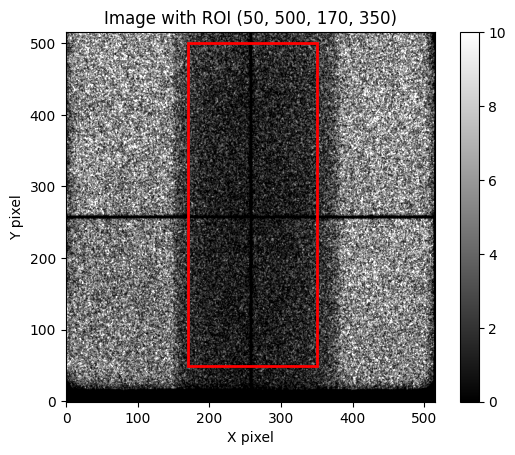

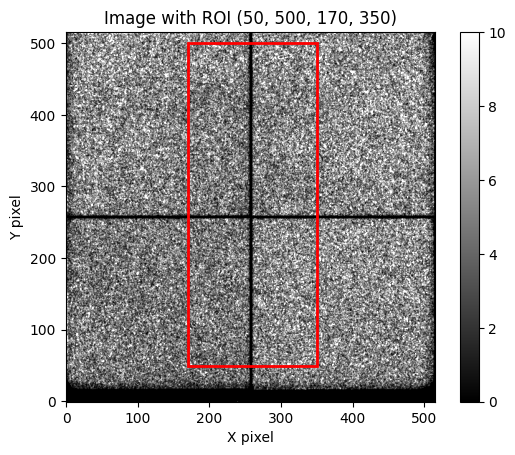

In [14]:
plot_image_with_roi(H_Ni[100], roi)
plot_image_with_roi(H_OB[100], roi)

### Extract TOF spectrum in ROI

In [15]:
tof_spectrum_Ni = extract_tof_spectrum_roi(H_Ni, roi)
tof_spectrum_OB= extract_tof_spectrum_roi(H_OB, roi)

In [16]:
# np.sum(tof_spectrum_Ni), np.sum(tof_spectrum_OB)
# (736166845, 1030717189)

### Check the tof spectra

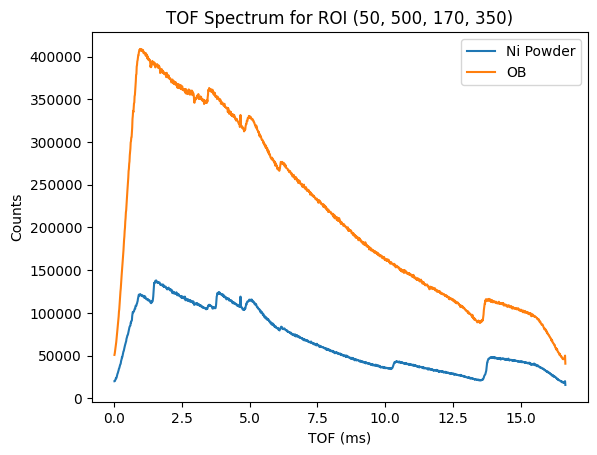

In [17]:
plt.plot(tof_edges[:-1]/1e6, tof_spectrum_Ni)
plt.plot(tof_edges[:-1]/1e6, tof_spectrum_OB)
plt.legend(['Ni Powder', 'OB'])
# plt.plot(tof_edges[:-1]/1e6, tof_spectrum_Ni_3)
# plt.plot(tof_edges[:-1]/1e6, tof_spectrum_Ni_4)
# plt.plot(tof_edges[:-1]/1e6, tof_spectrum_Ni_5)# Anton Tremsin likes to use the beginning of the edge to represent the bin
plt.xlabel('TOF (ms)')
plt.ylabel('Counts')
plt.title(f'TOF Spectrum for ROI {roi}')
plt.show()

### Transmission -> Attenuation


In [18]:
Transmission=  tof_spectrum_Ni/ tof_spectrum_OB
Vlad_TDC_Attenuation = 1 - Transmission

### TOF -> Wavelength

In [19]:
delay = 12005 # us
distance = 2500 
wave_tpx3_vlad = 0.3956*(delay + (tof_edges[:-1]/1e6)*1e3)/distance

wavelength_shift = 0.03  # [AA] This might come from the errors of source to detector distance and/or delay. Need to be evaluated.


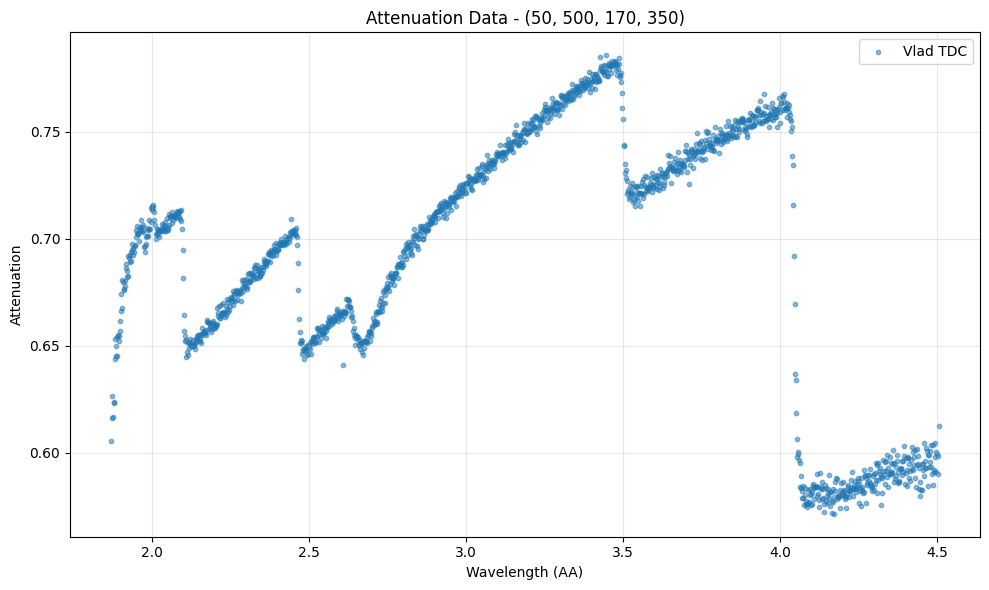

In [20]:



plt.figure(figsize=(10, 6))
# plt.errorbar(wave_tpx3, 1-Transmission, yerr=Transmission_error, label='Attenuation', alpha=0.7, marker='.', markersize=3, linestyle='-', linewidth=1)
plt.scatter(wave_tpx3_vlad-wavelength_shift, Vlad_TDC_Attenuation,  label='Vlad TDC',s=10, alpha=0.5)
# plt.scatter(Wavelength, Attenuation, label='Sophiread(v.2.0.0) with GDC',s=10, alpha=0.5)
plt.xlabel('Wavelength (AA)')
plt.ylabel('Attenuation')
plt.legend()
plt.title(f'Attenuation Data - {roi}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(f'At_wave_data_transmission_data_{roi}.png', dpi=300)
plt.show()

## Compare the obtained result with the total cross section of Ni and the result taken with sophiread (v2.0.0).

#### Read Ni powder Crossection data

In [21]:
cross_section_data = np.loadtxt('total_crossection_Ni.txt')
wavelength_cs = cross_section_data[:, 0]  # First column: wavelength
cross_section = cross_section_data[:, 1]  # Second column: cross-section

#### Read the bragg edge spectrum result analyzed with sophiread v.2.0.0. The input raw data for OB and Ni measurements are same (Run 8217 and 8216)

In [22]:
# File path
filepath = '/SNS/users/uff/VENUS_TPX3/Vlad_tpx3_analyss/t_wave_data_attenuation_data_(50, 500, 170, 350)_Run_8216_April25_2025_OB_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000_hits_old_sophiread.h5.txt'

# Load the data using numpy's loadtxt
data = np.loadtxt(filepath)
Wavelength = data[:, 0]  # First column
Attenuation = data[:, 1]  # Second column
# column3 = data[:, 2]  # Third column

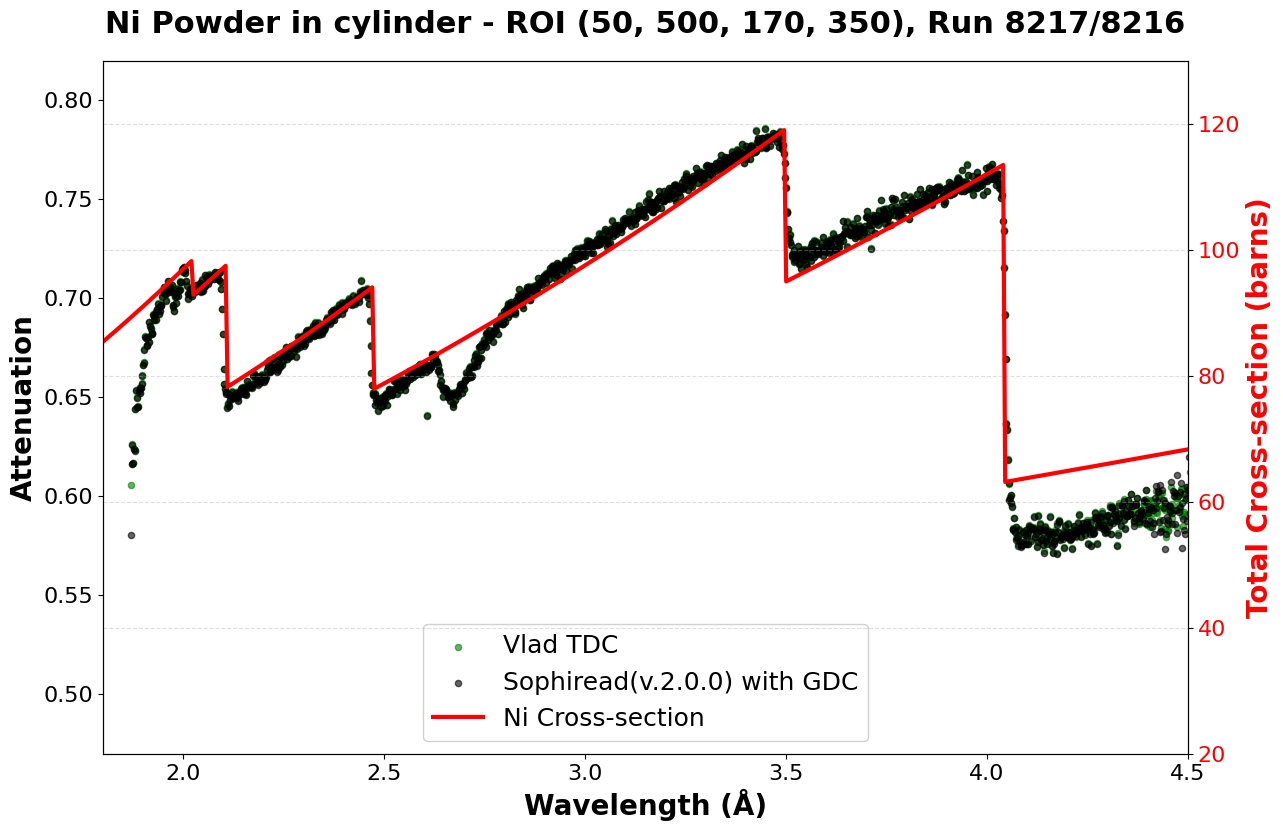

In [23]:

# Define font sizes
TITLE_SIZE = 22
LABEL_SIZE = 20
TICK_SIZE = 16
LEGEND_SIZE = 18

# Create figure with two y-axes
plt.figure(figsize=(14, 9))  # Larger figure size

# First y-axis for attenuation data
ax1 = plt.gca()
ax1.scatter(wave_tpx3_vlad-wavelength_shift, Vlad_TDC_Attenuation, label='Vlad TDC', s=20, alpha=0.6, color='green')
ax1.scatter(Wavelength-wavelength_shift, Attenuation, label='Sophiread(v.2.0.0) with GDC', s=20, alpha=0.6, color='black')
ax1.set_xlabel('Wavelength (Å)', fontsize=LABEL_SIZE, fontweight='bold')
ax1.set_ylabel('Attenuation', color='black', fontsize=LABEL_SIZE, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
ax1.set_ylim(0.47, 0.82)

# Second y-axis for cross-section data
ax2 = ax1.twinx()
ax2.plot(wavelength_cs, cross_section, 'r-', lw=3, label='Ni Cross-section')
ax2.set_ylabel('Total Cross-section (barns)', color='red', fontsize=LABEL_SIZE, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red', labelsize=TICK_SIZE)
ax2.set_ylim(20, 130)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center', fontsize=LEGEND_SIZE, framealpha=0.9)

# Set x-axis limits
plt.xlim(1.8, 4.5)

# Add title with larger font
plt.title(f'Ni Powder in cylinder - ROI {roi}, Run 8217/8216', 
          fontsize=TITLE_SIZE, fontweight='bold', pad=20)

# Add grid with better visibility
plt.grid(True, alpha=0.4, linestyle='--')

# Adjust layout
# plt.tight_layout()

# Save high-resolution figure
# plt.savefig(f'Attenuation_and_CrossSection_{roi}_large_fonts.png', dpi=300, bbox_inches='tight')
plt.show()